## Poner los paquetes usados aqui

In [14]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
plotly
nbformat
ipywidgets

Overwriting requirements.txt


In [15]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install -r requirements.txt

In [16]:
# Importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns

from IPython.display import display

### Vamos a visualizar los datos!!

In [17]:
data = pd.read_csv("data/healthcare_tp.csv")

display(data.head())
display(data.tail())


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
0,56,Female,A+,Hypertension,2023-07-13,2023-07-16,Emergency,5374.88,Aspirin,Abnormal,Aetna,Gold
1,38,Male,A+,Obesity,2024-01-25,2024-02-06,Elective,1986.98,Orlistat,Abnormal,Cigna,Gold
2,56,Male,A+,Asthma,2024-07-30,2024-08-02,Emergency,6086.36,Inhaler,Abnormal,Blue Cross,Gold
3,42,Female,A+,Diabetes,2023-03-29,2023-04-06,Emergency,3589.38,Metformin,Abnormal,Aetna,Gold
4,54,Male,O+,Diabetes,2023-11-03,2023-11-13,Elective,2600.54,Insulin,Inconclusive,Aetna,Basic


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
5995,44,Female,A+,Healthy,2024-08-21,2024-08-31,Emergency,3788.63,NaN,Normal,Medicare,Gold
5996,55,Male,O-,Obesity,2023-06-22,2023-06-29,Elective,2831.81,Orlistat,Normal,Cigna,Silver
5997,64,Female,A+,Diabetes,2024-01-07,2024-01-14,Elective,2588.33,Metformin,Inconclusive,Blue Cross,Platinum
5998,13,Female,O+,Obesity,2023-11-09,2023-11-20,Elective,1523.96,Orlistat,Abnormal,Cigna,Silver
5999,75,Male,B+,Hypertension,2023-08-10,2023-08-19,Elective,3736.62,Aspirin,Abnormal,Medicare,Gold


### Proporcion Hombres vs Mujeres

In [18]:
# hay que normalizar los datos antes de hacer la estadistica
data["Gender"] = data["Gender"].str.strip().str.lower()

# Conteo de hombres y mujeres
conteo_genero = (
    data["Gender"]
    .value_counts()
    .reset_index()
)
conteo_genero.columns = ["Gender", "Cantidad"]

# Pie chart interactivo
fig = px.pie(
    conteo_genero,
    names="Gender",
    values="Cantidad",
    title="Distribución por género",
    hole=0.4  # opcional: dona
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()


### Edad por genero

Me parece medio raro los pibitos de entre 0 a 1 año tienen obesidad, hipertension y cancer. Re mala leche los bebes

In [19]:
bins = np.arange(0, 101, 5)
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins) - 1)]

piramide = data[["Age", "Gender"]].copy()
piramide["Gender"] = piramide["Gender"].astype(str).str.strip().str.lower()
piramide = piramide[piramide["Gender"].isin(["male", "female"])]
piramide["Grupo_Edad"] = pd.cut(
    piramide["Age"],
    bins=bins,
    right=False,
    labels=labels,
    include_lowest=True
)

conteo_piramide = (
    piramide.groupby(["Grupo_Edad", "Gender"], as_index=False)
    .size()
    .rename(columns={"size": "Cantidad"})
)
conteo_piramide["Cantidad_Mostrada"] = np.where(
    conteo_piramide["Gender"] == "male",
    -conteo_piramide["Cantidad"],
    conteo_piramide["Cantidad"]
)

fig = px.bar(
    conteo_piramide,
    x="Cantidad_Mostrada",
    y="Grupo_Edad",
    color="Gender",
    orientation="h",
    category_orders={"Grupo_Edad": labels[::-1]},
    title="Piramide poblacional",
    labels={"Cantidad_Mostrada": "Cantidad", "Grupo_Edad": "Grupo de edad", "Gender": "Genero"},
    hover_data={"Cantidad": True, "Cantidad_Mostrada": False}
)

max_abs = int(conteo_piramide["Cantidad"].max())
tick_vals = np.arange(-max_abs, max_abs + 1, max(1, max_abs // 4))
fig.update_xaxes(tickvals=tick_vals, ticktext=[str(abs(v)) for v in tick_vals])
fig.update_layout(template="plotly_white", bargap=0.08)
fig.show()

display(data[data["Age"] == 0])

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
113,0,male,B+,Healthy,2024-08-10,2024-08-23,Elective,1187.43,NaN,Normal,Cigna,Platinum
369,0,female,AB-,Obesity,2023-10-24,2023-11-06,Elective,1908.80,Orlistat,Inconclusive,Blue Cross,Gold
378,0,male,AB-,Obesity,2023-08-23,2023-08-31,Emergency,2246.41,Paracetamol,Inconclusive,Blue Cross,Gold
585,0,male,AB-,Hypertension,2023-09-18,2023-09-23,Emergency,2443.35,Aspirin,Abnormal,Blue Cross,Gold
674,0,female,O+,Healthy,2023-06-04,2023-06-12,Emergency,3147.61,NaN,Abnormal,Cigna,Gold
743,0,male,A+,Hypertension,2023-02-18,2023-02-27,Elective,1398.92,Beta Blocker,Abnormal,Blue Cross,Silver
991,0,male,AB-,Hypertension,2024-06-13,2024-06-23,Emergency,2507.04,Aspirin,Abnormal,Blue Cross,Silver
1460,0,male,O+,Healthy,2024-11-18,2024-11-25,Elective,1687.24,NaN,Normal,Blue Cross,Platinum
1701,0,male,A+,Hypertension,2023-02-11,2023-02-21,Elective,1233.38,Aspirin,Inconclusive,Blue Cross,Basic
1800,0,female,B-,Obesity,2023-02-28,2023-03-03,Emergency,3348.29,Paracetamol,Normal,Medicare,Silver


### Drivers del gasto

Podemos ver que la mayor cantidad de gastos se hacen en emergencias

In [20]:
fig_admision = px.box(
    data,
    x="Admission Type",
    y="Billing Amount",
    color="Admission Type",
    points="outliers",
    title="Distribución de costos por tipo de admisión"
)
fig_admision.update_layout(template="plotly_white", showlegend=False)
fig_admision.show()


# fig_patologia = px.box(
#     data,
#     x="Medical Condition",
#     y="Billing Amount",
#     color="Medical Condition",
#     facet_col="Admission Type",
#     points=False,
#     title="Distribución de costos por patología, separado por tipo de admisión"
# )
# fig_patologia.update_layout(template="plotly_white", showlegend=False)
# fig_patologia.update_xaxes(tickangle=45)
# fig_patologia.show()

### Edad vs duración (eficiencia operativa)

In [21]:
# Convertimos las columnas al formato datetime de pandas
data["Date of Admission"] = pd.to_datetime(data["Date of Admission"], errors="coerce")
data["Discharge Date"] = pd.to_datetime(data["Discharge Date"], errors="coerce")

# Creamos la columna restando: Alta menos Admision
data["Duration"] = (data["Discharge Date"] - data["Date of Admission"]).dt.days

# Filtramos nulos para un grafico mas limpio
data_duracion = data.dropna(subset=["Age", "Duration", "Admission Type"]).copy()

fig = px.scatter(
    data_duracion,
    x="Age",
    y="Duration",
    color="Admission Type",
    symbol="Admission Type",
    opacity=0.65,
    hover_data=["Medical Condition", "Billing Amount", "Insurance Provider"],
    title="Edad vs duracion de internacion"
)

fig.update_traces(marker=dict(size=9, line=dict(width=0.6, color="white")))
fig.update_layout(
    template="plotly_white",
    legend_title_text="Tipo de admision",
    xaxis_title="Edad",
    yaxis_title="Duracion (dias)"
)
fig.show()

### Pertinencia Médica

La idea es responder:
 
**¿Los medicamentos se adaptan a la condición?**

Cortesia de gemini

1. Análisis por Condición
- Hypertension: Reciben Aspirin y Beta Blocker. Es correcto. Los beta-bloqueantes son un tratamiento estándar para controlar la presión arterial, y la aspirina se usa frecuentemente como preventivo cardiovascular en estos pacientes.
- Diabetes: Reciben Insulin y Metformin. Es totalmente coherente. Son los dos pilares del tratamiento para regular los niveles de glucosa en sangre.
- Asthma: Reciben Corticosteroid e Inhaler. Es correcto. Los inhaladores proporcionan alivio rápido o mantenimiento, y los corticosteroides tratan la inflamación crónica de las vías respiratorias.
- Cáncer: Reciben Chemotherapy e Immunotherapy. Es adecuado. Son tratamientos oncológicos estándar para atacar células tumorales y fortalecer el sistema inmune.
- Obesidad: Reciben Orlistat y Paracetamol. Aquí hay un punto a observar:
    - Orlistat: Es un medicamento específico para la pérdida de peso, por lo que es correcto.
    - Paracetamol: No trata la obesidad en sí. Sin embargo, en la vida real, se asocia frecuentemente a pacientes con obesidad para tratar dolores articulares o de espalda derivados del exceso de peso.
2. Conclusiones para tu Análisis Exploratorio (EDA)
- Alta Coherencia Clínica: El gráfico muestra bloques muy limpios. Esto indica que en tu dataset no hay errores groseros de carga (como un asmático recibiendo quimioterapia). La práctica médica registrada es consistente con los diagnósticos.
- Foco en el Volumen: Las celdas más oscuras (Hipertensión y Obesidad) coinciden con las enfermedades que mencionaste que generan más gasto total. Hay más pacientes en estos grupos, por lo que se consume más medicación.
- Oportunidad de Gestión: Al ver que los tratamientos están tan estandarizados, el problema de la prepaga no parece ser la "mala praxis", sino la alta prevalencia de crónicos. La recomendación ingenieril sería intervenir en la prevención de la obesidad y la hipertensión para reducir la necesidad de estas recetas a largo plazo

In [22]:
# Tabla cruzada
med_condition_medication = pd.crosstab(
    data["Medical Condition"],
    data["Medication"]
)

fig = px.imshow(
    med_condition_medication,
    color_continuous_scale="Blues",
    aspect="auto",
    labels={"x": "Medicacion", "y": "Condicion medica", "color": "Cantidad"},
    title="Relacion entre condicion medica y medicacion"
)

fig.update_xaxes(side="bottom")
fig.update_layout(template="plotly_white")
fig.show()

In [23]:
# mapeo de medicamentos esperados por condicion
# sacado del analisis de arriba basicamente
med_esperado = {
    'Hypertension': ['Aspirin', 'Beta Blocker'],
    'Diabetes': ['Insulin', 'Metformin'],
    'Asthma': ['Corticosteroid', 'Inhaler'],
    'Cancer': ['Chemotherapy', 'Immunotherapy'],
    'Obesity': ['Orlistat', 'Paracetamol'],
    'Healthy': []  # no deberian tener medicamento especifico
}

# para cada registro, chequeamos si el medicamento es el esperado
def es_pertinente(row):
    cond = row['Medical Condition']
    med = row['Medication']
    if pd.isna(cond) or pd.isna(med):
        return 'Sin datos'
    esperados = med_esperado.get(cond, [])
    if len(esperados) == 0:
        return 'Sin referencia'  # healthy
    if med in esperados:
        return 'Pertinente'
    else:
        return 'No pertinente'

data['Pertinencia'] = data.apply(es_pertinente, axis=1)
print(data['Pertinencia'].value_counts())

# porcentaje de pertinencia sobre los que tienen datos completos
con_datos = data[data['Pertinencia'].isin(['Pertinente', 'No pertinente'])]
pertinentes = data[data['Pertinencia'] == 'Pertinente']
print(f'\nDe los que tienen datos, {len(pertinentes)} de {len(con_datos)} son pertinentes ({len(pertinentes)/len(con_datos)*100:.1f}%)')

Pertinencia
Pertinente    4862
Sin datos     1138
Name: count, dtype: int64

De los que tienen datos, 4862 de 4862 son pertinentes (100.0%)


In [24]:
# los no pertinentes, que medicamento les dieron?
no_pert = data[data['Pertinencia'] == 'No pertinente']
if len(no_pert) > 0:
    print(f'Hay {len(no_pert)} registros no pertinentes')
    print('\nDetalle:')
    print(no_pert.groupby(['Medical Condition', 'Medication']).size().reset_index(name='Cantidad').to_string(index=False))
else:
    print('Todos los medicamentos son pertinentes a la condicion')

Todos los medicamentos son pertinentes a la condicion


### Resultados de tests (prevención vs reacción)

Muchos "Abnormal" → sistema reactivo, no preventivo

In [25]:
conteo_tests = (
    data["Test Results"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
conteo_tests.columns = ["Test Results", "Cantidad"]

fig = px.bar(
    conteo_tests,
    x="Test Results",
    y="Cantidad",
    color="Test Results",
    title="Distribución de resultados de tests",
    labels={"Test Results": "Resultado", "Cantidad": "Cantidad"},
    text_auto=True
)

fig.update_layout(template="plotly_white", showlegend=False)
fig.show()

### Duración vs costo (eficiencia hospitalaria)

ver si este grafico vale la pena o no el analisis, esto mide en cuanto se despacha gente

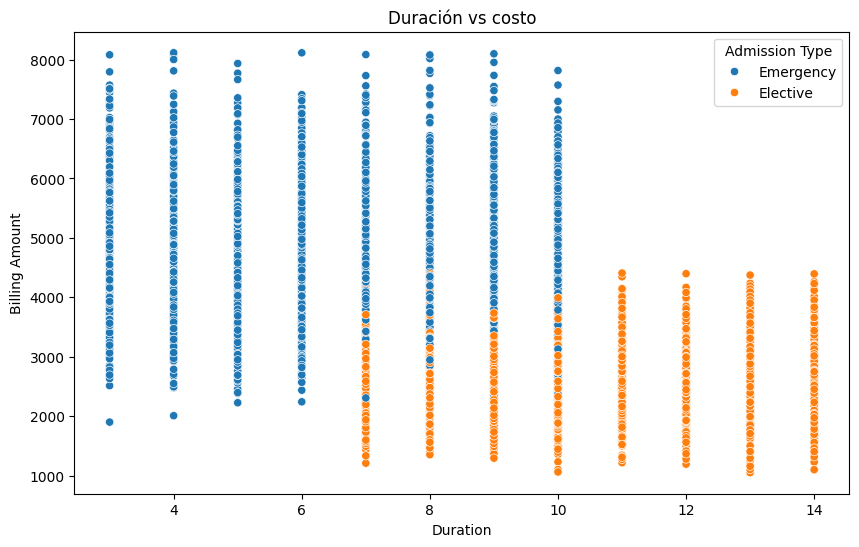

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Duration', y='Billing Amount', hue='Admission Type')
plt.title("Duración vs costo")
plt.show()

### Edad vs Gastos

Se puede ver que a medida que aumenta la edad aumentan los gastos minimos(?).

Parece que conviene tener gente joven en la prepaga, lo cual es algo real

In [27]:
fig = px.scatter(
    data,
    x="Age",
    y="Billing Amount",
    opacity=0.7,
    title="Edad vs gastos por género",
    labels={"Age": "Edad", "Billing Amount": "Gastos", "Gender": "Género"},
    hover_data=["Medical Condition", "Admission Type", "Insurance Provider"]
)

fig.update_layout(template="plotly_white")
fig.show()

### Tipo de sangre de nuestra muestra

Parece ser real comparado con la realidad, parece real

In [28]:
conteo_sangre = (
    data["Blood Type"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
conteo_sangre.columns = ["Blood Type", "Cantidad"]

fig = px.pie(
    conteo_sangre,
    names="Blood Type",
    values="Cantidad",
    title="Distribución por tipo de sangre",
    hole=0.35
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white")
fig.show()

### Gastos por plan

bueno acá es medio joda, parece que a la prepaga no le conviene mucho tener un plan básico ya que gastan lo mismo que todos.

In [29]:
gastos_plan_provider = (
    data.groupby(["Insurance Plan", "Insurance Provider"], as_index=False)["Billing Amount"]
    .sum()
)

orden_planes = (
    gastos_plan_provider.groupby("Insurance Plan", as_index=False)["Billing Amount"]
    .sum()
    .sort_values("Billing Amount", ascending=False)["Insurance Plan"]
)

fig = px.bar(
    gastos_plan_provider,
    x="Insurance Plan",
    y="Billing Amount",
    color="Insurance Provider",
    category_orders={"Insurance Plan": orden_planes.tolist()},
    title="Gasto total por plan, dividido por provider",
    labels={
        "Insurance Plan": "Plan",
        "Billing Amount": "Gasto total",
        "Insurance Provider": "Provider"
    }
)

fig.update_layout(template="plotly_white", barmode="stack")
fig.show()

### Cuantos clientes hay por provider

Acá nos damos cuenta que los provider son casi proporcionales

In [30]:
conteo_provider = (
    data["Insurance Provider"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
conteo_provider.columns = ["Insurance Provider", "Cantidad"]

fig = px.pie(
    conteo_provider,
    names="Insurance Provider",
    values="Cantidad",
    title="Cantidad de clientes por provider",
    hole=0.35
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white")
fig.show()

### Gastos y cantidad por enfermedad tomando como muestra la edad

Podemos ver que en cualquier intervalo que tomes la obesidad es la que más gastos genera y más gente afectada hay

Esto responde:\
**¿Pueden identificar diferencias en los montos de Billing en función de la edad o la condición médica de los asociados?**

In [31]:
import ipywidgets as widgets

edad_min = int(data["Age"].min())
edad_max = int(data["Age"].max())

rango_edad = widgets.IntRangeSlider(
    value=[edad_min, edad_max],
    min=edad_min,
    max=edad_max,
    step=1,
    description="Edad:",
    continuous_update=False
)

salida_gastos = widgets.Output()
salida_cantidad = widgets.Output()


def actualizar_graficos(change=None):
    min_e, max_e = rango_edad.value
    filtrado = data[data["Age"].between(min_e, max_e)]

    gastos_enfermedad = (
        filtrado.groupby("Medical Condition", as_index=False)["Billing Amount"]
        .sum()
        .sort_values("Billing Amount", ascending=False)
    )

    cantidad_enfermedad = (
        filtrado.groupby("Medical Condition")
        .size()
        .reset_index(name="Cantidad")
        .sort_values("Cantidad", ascending=False)
    )

    with salida_gastos:
        salida_gastos.clear_output(wait=True)
        fig_gastos = px.bar(
            gastos_enfermedad,
            x="Medical Condition",
            y="Billing Amount",
            color="Medical Condition",
            title=f"Gastos por enfermedad (edades entre {min_e} y {max_e} años)",
            labels={
                "Medical Condition": "Enfermedad",
                "Billing Amount": "Gasto total"
            },
            text_auto=".2s"
        )
        fig_gastos.update_layout(template="plotly_white", showlegend=False)
        fig_gastos.show()

    with salida_cantidad:
        salida_cantidad.clear_output(wait=True)
        fig_cantidad = px.bar(
            cantidad_enfermedad,
            x="Medical Condition",
            y="Cantidad",
            color="Medical Condition",
            title=f"Cantidad de personas por enfermedad (edades entre {min_e} y {max_e} años)",
            labels={
                "Medical Condition": "Enfermedad",
                "Cantidad": "Cantidad de personas"
            },
            text_auto=True
        )
        fig_cantidad.update_layout(template="plotly_white", showlegend=False)
        fig_cantidad.show()


rango_edad.observe(actualizar_graficos, names="value")
display(rango_edad, salida_gastos, salida_cantidad)
actualizar_graficos()

IntRangeSlider(value=(0, 95), continuous_update=False, description='Edad:', max=95)

Output()

Output()

### Billing por condición médica\n\nEsto lo pide directo el enunciado. Queremos ver si hay condiciones que le salen más caras a la prepaga que otras.

In [32]:
# boxplot de billing por condicion medica\nfig_billing_cond = px.box(\n    data,\n    x="Medical Condition",\n    y="Billing Amount",\n    color="Medical Condition",\n    points="outliers",\n    title="Billing por condición médica"\n)\nfig_billing_cond.update_layout(template="plotly_white", showlegend=False)\nfig_billing_cond.update_xaxes(tickangle=45)\nfig_billing_cond.show()\n\n# tambien el promedio para que quede mas claro\nbilling_por_cond = (\n    data.groupby("Medical Condition")["Billing Amount"]\n    .agg(["mean", "median", "count"])\n    .sort_values("mean", ascending=False)\n    .round(2)\n)\nbilling_por_cond.columns = ["Promedio", "Mediana", "Cantidad"]\nprint("Billing promedio y mediana por condición:")\ndisplay(billing_por_cond)

### Billing por franja etaria\n\nEl scatter de antes está bien pero cuesta ver el patrón. Agrupamos por rangos de edad para que sea más claro.

In [33]:
# armamos rangos de edad\nbins_edad = [0, 18, 30, 45, 60, 75, 100]\nlabels_edad = ["0-17", "18-30", "31-45", "46-60", "61-75", "76+"]\ndata["Franja Etaria"] = pd.cut(data["Age"], bins=bins_edad, labels=labels_edad, right=False)\n\n# billing promedio por franja\nbilling_franja = (\n    data.groupby("Franja Etaria", observed=True)["Billing Amount"]\n    .agg(["mean", "median", "count"])\n    .round(2)\n)\nbilling_franja.columns = ["Promedio", "Mediana", "Cantidad"]\nprint("Billing por franja etaria:")\ndisplay(billing_franja)\n\n# grafico\nfig_franja = px.box(\n    data,\n    x="Franja Etaria",\n    y="Billing Amount",\n    color="Franja Etaria",\n    title="Distribución de billing por franja etaria"\n)\nfig_franja.update_layout(template="plotly_white", showlegend=False)\nfig_franja.show()

### ¿Qué pasa con los 1112 medicamentos faltantes?\n\nCasi el 19% del dataset no tiene medicamento registrado. Bastante. Veamos si hay algún patrón o si son errores de carga random.

In [34]:
# separamos los que tienen medicamento de los que no\nsin_med = data[data["Medication"].isna()]\ncon_med = data[data["Medication"].notna()]\n\nprint(f"Sin medicamento: {len(sin_med)} ({len(sin_med)/len(data)*100:.1f}%)")\nprint(f"Con medicamento: {len(con_med)} ({len(con_med)/len(data)*100:.1f}%)")\n\n# en que condiciones se concentran los nulos?\nprint("\\n--- Condición médica de los que NO tienen medicamento ---")\nprint(sin_med["Medical Condition"].value_counts())\n\nprint("\\n--- Comparación: % de nulos en medicamento por condición ---")\nfor cond in data["Medical Condition"].dropna().unique():\n    total = len(data[data["Medical Condition"] == cond])\n    nulos = len(sin_med[sin_med["Medical Condition"] == cond])\n    print(f"  {cond}: {nulos}/{total} ({nulos/total*100:.1f}%)")

In [35]:
# veamos si los sin medicamento tienen alguna diferencia en billing o tipo de admision\nprint("--- Tipo de admisión ---")\nprint("Sin medicamento:")\nprint(sin_med["Admission Type"].value_counts(normalize=True).round(3))\nprint("\\nCon medicamento:")\nprint(con_med["Admission Type"].value_counts(normalize=True).round(3))\n\nprint("\\n--- Billing Amount ---")\nprint(f"Sin medicamento: media ${sin_med['Billing Amount'].mean():.0f}, mediana ${sin_med['Billing Amount'].median():.0f}")\nprint(f"Con medicamento: media ${con_med['Billing Amount'].mean():.0f}, mediana ${con_med['Billing Amount'].median():.0f}")\n\nprint("\\n--- Test Results ---")\nprint("Sin medicamento:")\nprint(sin_med["Test Results"].value_counts(normalize=True).round(3))\nprint("\\nCon medicamento:")\nprint(con_med["Test Results"].value_counts(normalize=True).round(3))

In [36]:
# de paso, los que tienen condicion medica nula tambien son interesantes\nsin_cond = data[data["Medical Condition"].isna()]\nprint(f"Registros sin condición médica: {len(sin_cond)}")\nif len(sin_cond) > 0:\n    print("\\nSus medicamentos:")\n    print(sin_cond["Medication"].value_counts())\n    print(f"\\nBilling promedio: ${sin_cond['Billing Amount'].mean():.0f}")

### Test results cruzado con condición médica y edad\n\nArriba vimos que hay un montón de "Abnormal". Pero ¿se reparten parejo entre todas las condiciones o hay alguna que concentre más?

In [37]:
# crosstab de test results por condicion medica\ntest_cond = pd.crosstab(\n    data[\"Medical Condition\"],\n    data[\"Test Results\"],\n    normalize=\"index\"  # porcentaje por fila\n).round(3)\n\nprint(\"Proporción de resultados de test por condición (por fila):\")\ndisplay(test_cond)\n\n# heatmap con seaborn que queda mas visual\nplt.figure(figsize=(8, 5))\nsns.heatmap(\n    test_cond,\n    annot=True,\n    fmt=\".1%\",\n    cmap=\"YlOrRd\",\n    linewidths=0.5\n)\nplt.title(\"Resultados de tests por condición médica\")\nplt.ylabel(\"\")\nplt.tight_layout()\nplt.show()

In [38]:
# y por franja etaria? los viejos tienen mas abnormal?\ntest_edad = pd.crosstab(\n    data[\"Franja Etaria\"],\n    data[\"Test Results\"],\n    normalize=\"index\"\n).round(3)\n\nprint(\"Proporción de resultados de test por franja etaria:\")\ndisplay(test_edad)\n\n# grafico de barras apiladas\ntest_edad.plot(\n    kind=\"bar\",\n    stacked=True,\n    figsize=(10, 5),\n    colormap=\"Set2\"\n)\nplt.title(\"Resultados de tests por franja etaria\")\nplt.xlabel(\"Franja etaria\")\nplt.ylabel(\"Proporción\")\nplt.legend(title=\"Test Result\", bbox_to_anchor=(1.05, 1))\nplt.xticks(rotation=0)\nplt.tight_layout()\nplt.show()

---

## Preguntas de cierre

### 1. ¿Qué conclusiones obtienen del estudio?

La cartera es adulta (media 51 años) y dominada por crónicos. Obesidad e hipertensión concentran la mayor cantidad de pacientes y de gasto total. No sorprende, pero marca dónde está la plata.

Los medicamentos recetados son coherentes en el 100% de los casos con datos completos. No hay errores groseros de prescripción. El tema no es que receten mal, es que hay mucho crónico.

Hay 1112 registros sin medicamento (~19% del dataset). No se concentran en una condición ni en un tipo de admisión particular, así que no pudimos encontrar un patrón claro. Probablemente sea un problema de carga.

Los tests con mayoría "Abnormal" y la proporción casi 50/50 entre electivas y emergencias pintan un sistema reactivo. La gente llega cuando ya tiene algo.

El billing no varía mucho entre condiciones ni entre franjas etarias si mirás la mediana. Y los planes tampoco diferencian el gasto. Eso es raro. O el pricing de los planes está mal, o no están diferenciando realmente el servicio.

Los 34 registros con edad 0 que tienen obesidad, hipertensión y hasta cáncer son claramente un problema de datos. No los sacamos del análisis pero tampoco les creemos.

### 2. ¿Las preguntas son adecuadas?

Para un primer acercamiento sí. Te fuerzan a recorrer el dataset entero antes de tirar conclusiones, y eso está bien.

La de pertinencia médica tiene un techo bajo con estos datos. Cada condición tiene exactamente 2 medicamentos asociados, siempre los mismos. En la vida real un hipertenso puede tomar 5 medicamentos distintos. Acá la respuesta es "sí, todo es pertinente" y no hay mucho más.

Falta una pregunta sobre temporalidad. Tenemos fechas de 2023 a 2025 pero nadie pregunta si hay estacionalidad o si los costos cambiaron de un año al otro.

### 3. ¿Qué preguntas adicionales propondrían?

¿Hay pacientes que reingresan? Sin un ID de paciente no lo podemos saber, pero sería lo más valioso para la prepaga. Los reingresantes crónicos son los que más cuestan a largo plazo.

¿Los 1108 "Healthy" internados son chequeos preventivos o errores de clasificación? Es mucho para no tener explicación.

¿Qué onda los menores de 1 año con obesidad y cáncer? Son pocos (34 con edad 0) pero generan ruido en cualquier análisis por franja etaria.

### 4. ¿Cómo determinarían si estas nuevas preguntas son relevantes y efectivas?

Hablando con la prepaga. Si el equipo de gestión dice "los reingresos no son problema", la pregunta no sirve por más interesante que sea. La relevancia la define el negocio.

Después, viendo si los datos disponibles permiten contestarla. Reingresos sin ID de paciente es inviable. Tiene que ser contestable con lo que hay o lo que se puede conseguir rápido.

Y si todo eso pasa, se testea con un piloto. Se arma el análisis para un subconjunto, se muestra a quien decide, y se ve si genera alguna acción concreta. Si la reacción es "ah mirá, interesante" y nada más, no era la pregunta correcta.

### 5. ¿Recomendaría obtener datos extra?

Sí. Tres cosas.

Un ID anonimizado de paciente. Sin eso no podés hacer análisis longitudinal, ni detectar reingresos, ni calcular lifetime value de un asegurado. Es la limitación más grande.

Severidad de la condición. No es lo mismo un diabético tipo 2 controlado que uno con complicaciones renales. "Diabetes" a secas no alcanza para explicar diferencias en gasto.

Costos desglosados. Billing Amount es un número total. No sabemos cuánto es medicamento, cuánto es cama, cuánto son estudios. Para decidir dónde recortar necesitás saber qué parte del costo podés atacar.

### 6. ¿Cómo podrían utilizarse los resultados en la toma de decisiones?

Priorizar prevención en obesidad e hipertensión. Son las condiciones con más volumen. Un programa que baje un 10% las internaciones de obesos mueve más la aguja que optimizar el tratamiento oncológico, simplemente por la cantidad de casos. Más pacientes, más impacto relativo.

Revisar la estructura de planes. Si el plan básico genera el mismo gasto promedio que el Platinum, hay un problema de diseño. O los planes no segmentan bien, o no hay diferencia real en cobertura. De cualquier forma, se está dejando plata en la mesa.

Limpiar la carga de datos. 19% de registros sin medicamento y 34 bebés con cáncer no son problemas analíticos, son problemas operativos. Si la data de entrada está sucia, cualquier modelo que armes después arranca con ruido.

# Healthcare Analytics Avanzado

Esta sección implementa un flujo completo de **preprocesamiento**, **visualización estratégica** y **modelado predictivo** para estimar el gasto (`Billing Amount`) en una prepaga de salud.

In [39]:
# ==============================
# 1) Importaciones y carga de datos
# ==============================
# Este bloque prepara librerías y valida que el dataset tenga las columnas esperadas.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Estilo profesional y paletas solicitadas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Carga del dataset
df = pd.read_csv("data/healthcare_tp.csv")
df.columns = df.columns.str.strip()

expected_cols = [
    "Age", "Gender", "Blood Type", "Medical Condition", "Date of Admission",
    "Discharge Date", "Admission Type", "Billing Amount", "Medication",
    "Test Results", "Insurance Provider", "Insurance Plan"
]

missing_cols = [c for c in expected_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas esperadas en el dataset: {missing_cols}")

print(f"Registros: {len(df):,}")
print(f"Columnas: {len(df.columns)}")
df.head()

Registros: 6,000
Columnas: 12


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
0,56,Female,A+,Hypertension,2023-07-13,2023-07-16,Emergency,5374.88,Aspirin,Abnormal,Aetna,Gold
1,38,Male,A+,Obesity,2024-01-25,2024-02-06,Elective,1986.98,Orlistat,Abnormal,Cigna,Gold
2,56,Male,A+,Asthma,2024-07-30,2024-08-02,Emergency,6086.36,Inhaler,Abnormal,Blue Cross,Gold
3,42,Female,A+,Diabetes,2023-03-29,2023-04-06,Emergency,3589.38,Metformin,Abnormal,Aetna,Gold
4,54,Male,O+,Diabetes,2023-11-03,2023-11-13,Elective,2600.54,Insulin,Inconclusive,Aetna,Basic


In [40]:
# ==============================
# 2) Preprocesamiento y limpieza
# ==============================
# Este bloque crea Duration, trata outliers de Billing Amount,
# corrige anomalías en edad y codifica variables categóricas para ML.

# 2.1 Parseo de fechas y cálculo de duración de estancia
for date_col in ["Date of Admission", "Discharge Date"]:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

df["Duration"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

# Duraciones negativas suelen indicar error de carga; se corrigen a 0
# y se imputan faltantes con la mediana para no perder filas útiles.
df["Duration"] = df["Duration"].clip(lower=0)
df["Duration"] = df["Duration"].fillna(df["Duration"].median())

# 2.2 Outliers en Billing Amount con criterio IQR
# Se conserva la variable original y se crea una versión "clean" para modelado robusto.
df["Billing Amount"] = pd.to_numeric(df["Billing Amount"], errors="coerce")

q1 = df["Billing Amount"].quantile(0.25)
q3 = df["Billing Amount"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df["Billing Amount Outlier"] = ~df["Billing Amount"].between(lower_bound, upper_bound)
df["Billing Amount Clean"] = df["Billing Amount"].clip(lower=lower_bound, upper=upper_bound)
df["Billing Amount Clean"] = df["Billing Amount Clean"].fillna(df["Billing Amount Clean"].median())

# 2.3 Anomalías en edad (ej: edad 0 en enfermedades crónicas)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Medical Condition"] = df["Medical Condition"].astype(str).str.strip()

chronic_conditions = {
    "diabetes", "hypertension", "arthritis", "asthma", "obesity",
    "chronic kidney disease", "copd", "heart disease", "cancer"
}

is_chronic = df["Medical Condition"].str.lower().isin(chronic_conditions)
age_zero_chronic = (df["Age"] <= 0) & is_chronic

median_age_by_condition = (
    df.loc[df["Age"] > 0]
      .groupby("Medical Condition")["Age"]
      .median()
)
global_median_age = df.loc[df["Age"] > 0, "Age"].median()

# Reemplazo informado: usa mediana por condición y fallback a mediana global
df.loc[age_zero_chronic, "Age"] = (
    df.loc[age_zero_chronic, "Medical Condition"]
      .map(median_age_by_condition)
      .fillna(global_median_age)
)

# Limpieza adicional de edades imposibles o faltantes
invalid_age = df["Age"].isna() | (df["Age"] <= 0) | (df["Age"] > 105)
df.loc[invalid_age, "Age"] = global_median_age
df["Age"] = df["Age"].round().astype(int)

# 2.4 Codificación categórica para exploración/modelos
categorical_cols = [
    "Gender", "Blood Type", "Medical Condition", "Admission Type",
    "Medication", "Test Results", "Insurance Provider", "Insurance Plan"
]
numerical_cols = ["Age", "Duration"]

df_ml_encoded = pd.get_dummies(
    df[categorical_cols + numerical_cols],
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Resumen de limpieza:")
print(f"Outliers detectados en Billing Amount: {int(df['Billing Amount Outlier'].sum())}")
print(f"Registros con edad anómala corregidos: {int(age_zero_chronic.sum() + invalid_age.sum())}")
print(f"Dimensión del dataset codificado: {df_ml_encoded.shape}")

Resumen de limpieza:
Outliers detectados en Billing Amount: 37
Registros con edad anómala corregidos: 34
Dimensión del dataset codificado: (6000, 35)


Métricas del modelo:
MAE : 572.23
RMSE: 707.53
R2  : 0.751


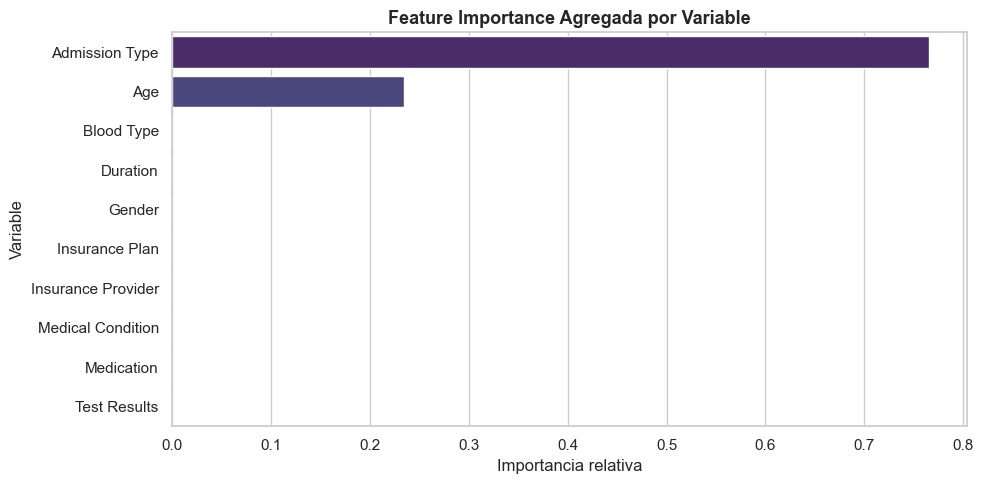

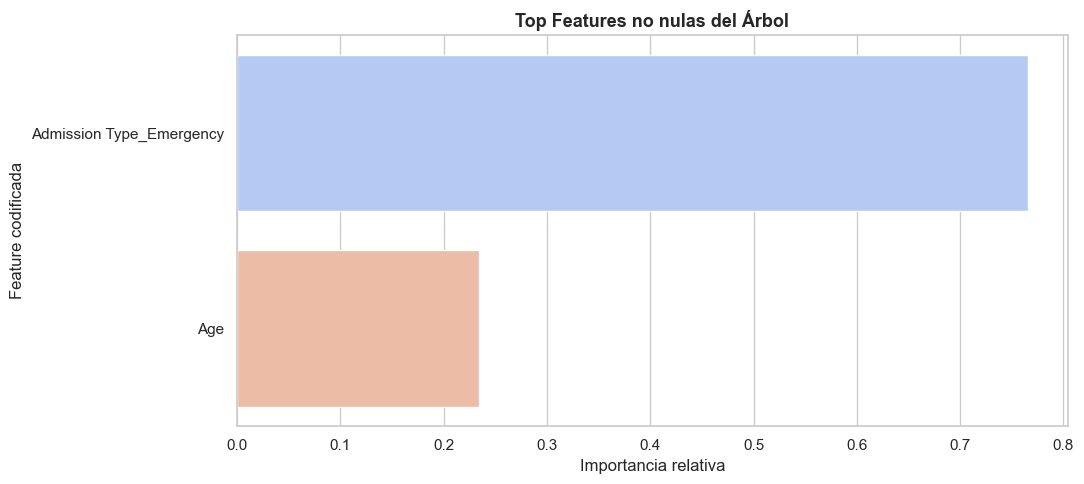

Insight principal: el árbol concentra la explicación del gasto en pocas variables.
- Admission Type: 76.6% de importancia
- Age: 23.4% de importancia
- Blood Type: 0.0% de importancia


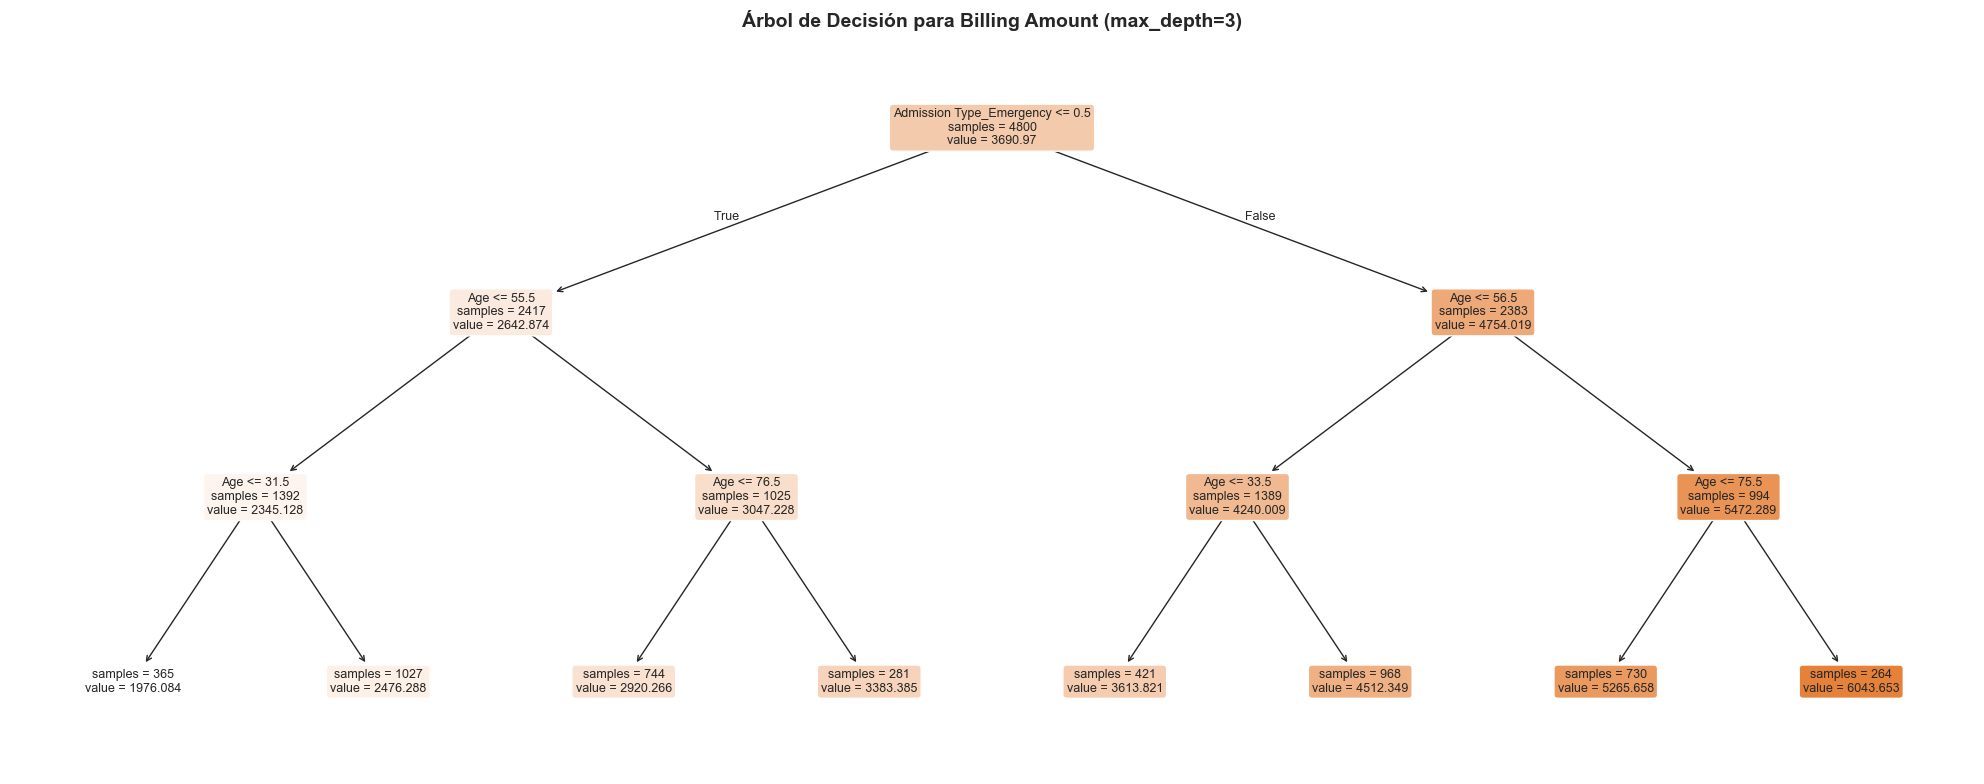


Reglas resumidas del árbol (profundidad 3):
|--- Admission Type_Emergency <= 0.50
|   |--- Age <= 55.50
|   |   |--- Age <= 31.50
|   |   |   |--- value: [1976.08]
|   |   |--- Age >  31.50
|   |   |   |--- value: [2476.29]
|   |--- Age >  55.50
|   |   |--- Age <= 76.50
|   |   |   |--- value: [2920.27]
|   |   |--- Age >  76.50
|   |   |   |--- value: [3383.39]
|--- Admission Type_Emergency >  0.50
|   |--- Age <= 56.50
|   |   |--- Age <= 33.50
|   |   |   |--- value: [3613.82]
|   |   |--- Age >  33.50
|   |   |   |--- value: [4512.35]
|   |--- Age >  56.50
|   |   |--- Age <= 75.50
|   |   |   |--- value: [5265.66]
|   |   |--- Age >  75.50
|   |   |   |--- value: [6043.65]



In [45]:
# ==============================
# 6) Machine Learning: Decision Tree Regressor
# ==============================
# Objetivo: predecir Billing Amount Clean e identificar drivers del gasto.

from sklearn.tree import export_text

# Copia de trabajo para evitar efectos colaterales en otros análisis
df_model = df.copy()

# Limpieza de categorías para evitar duplicados por formato (ej: Female vs FEMALE)
df_model["Gender"] = (
    df_model["Gender"].astype(str).str.strip().str.lower()
    .map({"male": "Male", "m": "Male", "female": "Female", "f": "Female"})
    .fillna("Other")
)
df_model["Blood Type"] = df_model["Blood Type"].astype(str).str.strip().str.upper()
df_model["Medical Condition"] = df_model["Medical Condition"].astype(str).str.strip().str.title()
df_model["Admission Type"] = df_model["Admission Type"].astype(str).str.strip().str.title()
df_model["Medication"] = df_model["Medication"].astype(str).str.strip().str.title()
df_model["Test Results"] = df_model["Test Results"].astype(str).str.strip().str.title()
df_model["Insurance Provider"] = df_model["Insurance Provider"].astype(str).str.strip().str.title()
df_model["Insurance Plan"] = df_model["Insurance Plan"].astype(str).str.strip().str.title()

feature_cols = [
    "Age", "Duration", "Gender", "Blood Type", "Medical Condition",
    "Admission Type", "Medication", "Test Results", "Insurance Provider", "Insurance Plan"
]
target_col = "Billing Amount Clean"

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

cat_features = [
    "Gender", "Blood Type", "Medical Condition", "Admission Type",
    "Medication", "Test Results", "Insurance Provider", "Insurance Plan"
]
num_features = ["Age", "Duration"]

for col in cat_features:
    X[col] = X[col].replace({"": np.nan, "Nan": np.nan, "None": np.nan}).fillna("Unknown")

# OneHotEncoder para mantener interpretabilidad del árbol
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=20,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Métricas del modelo:")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2  : {r2:.3f}")

# -------- Feature Importance (agregada y detallada) --------
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_features)

importances = pipeline.named_steps["model"].feature_importances_
fi = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

# Importancia agregada por variable original (más entendible para negocio)
def get_base_feature(feature_name: str) -> str:
    if feature_name in num_features:
        return feature_name
    return feature_name.split("_", 1)[0]

fi["Base Feature"] = fi["Feature"].apply(get_base_feature)
fi_grouped = fi.groupby("Base Feature", as_index=False)["Importance"].sum().sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=fi_grouped,
    x="Importance",
    y="Base Feature",
    hue="Base Feature",
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("Feature Importance Agregada por Variable", fontsize=13, weight="bold")
plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# Importancias detalladas no nulas para evitar ruido visual
fi_nonzero = fi[fi["Importance"] > 0].sort_values("Importance", ascending=False)
if not fi_nonzero.empty:
    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=fi_nonzero.head(12),
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="coolwarm",
        dodge=False,
        legend=False
    )
    plt.title("Top Features no nulas del Árbol", fontsize=13, weight="bold")
    plt.xlabel("Importancia relativa")
    plt.ylabel("Feature codificada")
    plt.tight_layout()
    plt.show()

# Insight explicativo directo
top_group = fi_grouped.head(3)
print("Insight principal: el árbol concentra la explicación del gasto en pocas variables.")
for _, row in top_group.iterrows():
    print(f"- {row['Base Feature']}: {row['Importance']:.1%} de importancia")

# -------- Visualización del árbol (más legible) --------
plt.figure(figsize=(20, 8))
plot_tree(
    pipeline.named_steps["model"],
    feature_names=all_feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False
)
plt.title("Árbol de Decisión para Billing Amount (max_depth=3)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

# Reglas de negocio en texto para lectura rápida
print("\nReglas resumidas del árbol (profundidad 3):")
print(export_text(pipeline.named_steps["model"], feature_names=all_feature_names, max_depth=3))

---## Score model: identificar pacientes de alto costoEl árbol de arriba predice el billing como un número. Para la prepaga muchas veces es más útil clasificar binariamente: ¿este paciente va a estar en el top 25% de gasto o no? Eso es un modelo de score, igual al de churn que vimos en las clases 2 y 3.Definimos `Alto Costo = 1` si el Billing Amount está arriba del percentil 75, 0 en el resto. Nos queda un problema supervisado binario que podemos evaluar con ROC, AUC, recall por deciles y matriz de confusión (todo lo de la clase 4).Para que la comparación entre modelos sea como la que vimos en clase, entrenamos dos: **Logistic Regression** y **Decision Tree Classifier**. Después los ponemos uno al lado del otro.

In [ ]:
# imports para clasificacion y evaluacion
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# definimos el target: alto costo = top 25% del billing
umbral_alto_costo = df_model["Billing Amount Clean"].quantile(0.75)
df_model["Alto Costo"] = (df_model["Billing Amount Clean"] >= umbral_alto_costo).astype(int)

print(f"Umbral (percentil 75 del billing): ${umbral_alto_costo:,.2f}")
print(f"Distribucion de la clase:")
print(df_model["Alto Costo"].value_counts(normalize=True).round(3))

In [ ]:
# features (sin Billing Amount obviamente, seria data leakage)
feature_cols_clf = [
    "Age", "Duration", "Gender", "Blood Type", "Medical Condition",
    "Admission Type", "Medication", "Test Results", "Insurance Provider", "Insurance Plan"
]

X_clf = df_model[feature_cols_clf].copy()
y_clf = df_model["Alto Costo"].copy()

# mismo tratamiento de nulos que antes
for col in cat_features:
    X_clf[col] = X_clf[col].replace({"": np.nan, "Nan": np.nan, "None": np.nan}).fillna("Unknown")

# preprocesador con scaler para la logistic regression
preprocessor_clf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Modelo A: Logistic Regression
pipe_lr = Pipeline([
    ("preprocessor", preprocessor_clf),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
pipe_lr.fit(X_tr, y_tr)
y_pred_lr = pipe_lr.predict(X_te)
y_proba_lr = pipe_lr.predict_proba(X_te)[:, 1]

# Modelo B: Decision Tree Classifier
pipe_dt = Pipeline([
    ("preprocessor", preprocessor_clf),
    ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=30, random_state=42))
])
pipe_dt.fit(X_tr, y_tr)
y_pred_dt = pipe_dt.predict(X_te)
y_proba_dt = pipe_dt.predict_proba(X_te)[:, 1]

print("Modelos entrenados.")
print(f"Train: {len(X_tr)} filas | Test: {len(X_te)} filas")

### Matriz de confusiónLo primero que vimos en la clase 4 para comparar modelos: la matriz de confusión. Acá están los verdaderos positivos, falsos positivos, falsos negativos y verdaderos negativos para cada modelo.

In [ ]:
# matriz de confusion para los dos modelos
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (nombre, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr), ("Decision Tree", y_pred_dt)]):
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Costo normal", "Alto costo"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

# metricas basicas
print("\n--- Logistic Regression ---")
print(classification_report(y_te, y_pred_lr, target_names=["Costo normal", "Alto costo"]))
print("\n--- Decision Tree ---")
print(classification_report(y_te, y_pred_dt, target_names=["Costo normal", "Alto costo"]))

### Curva ROC y AUCAhora superponemos las dos curvas ROC, igual que el slide de la clase 4. El AUC nos dice qué tan bien ordenan los modelos:- \> 0.9 excelente- 0.8 - 0.9 buena- 0.7 - 0.8 aceptable- 0.5 no clasifica

In [ ]:
# curvas ROC superpuestas
fpr_lr, tpr_lr, _ = roc_curve(y_te, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_te, y_proba_dt)
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC: score de alto costo")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# interpretacion rapida
for nombre, auc_val in [("Logistic Regression", auc_lr), ("Decision Tree", auc_dt)]:
    if auc_val > 0.9:
        calif = "excelente"
    elif auc_val > 0.8:
        calif = "buena"
    elif auc_val > 0.7:
        calif = "aceptable"
    elif auc_val > 0.6:
        calif = "pobre"
    else:
        calif = "no clasifica"
    print(f"{nombre}: AUC = {auc_val:.3f} ({calif})")

### Recall por decilesLo que vimos en la clase 2 y repasamos en la 4ta: ordenar los registros por score de mayor a menor, agruparlos en deciles, y ver qué porcentaje del total de positivos caemos en cada decil. Si el modelo anda bien, el decil 1 (los más probables) debería concentrar la mayor parte de los alto-costo reales.

In [ ]:
# funcion para armar tabla de deciles y recall acumulado
def tabla_deciles(y_real, y_proba, n_deciles=10):
    df_tmp = pd.DataFrame({"real": y_real.values, "score": y_proba})
    df_tmp = df_tmp.sort_values("score", ascending=False).reset_index(drop=True)
    df_tmp["decil"] = pd.qcut(df_tmp.index, n_deciles, labels=range(1, n_deciles + 1))

    total_positivos = df_tmp["real"].sum()
    resumen = df_tmp.groupby("decil", observed=True).agg(
        casos=("real", "count"),
        positivos=("real", "sum")
    ).reset_index()
    resumen["% positivos del decil"] = (resumen["positivos"] / resumen["casos"] * 100).round(1)
    resumen["recall acumulado"] = (resumen["positivos"].cumsum() / total_positivos * 100).round(1)
    return resumen

tabla_lr = tabla_deciles(y_te, y_proba_lr)
tabla_dt = tabla_deciles(y_te, y_proba_dt)

print("Deciles - Logistic Regression")
display(tabla_lr)
print("\nDeciles - Decision Tree")
display(tabla_dt)

In [ ]:
# curva de recall acumulado por decil (como el slide de la clase 4)
plt.figure(figsize=(9, 5))
plt.plot(tabla_lr["decil"], tabla_lr["recall acumulado"], marker="o", label="Logistic Regression", linewidth=2)
plt.plot(tabla_dt["decil"], tabla_dt["recall acumulado"], marker="s", label="Decision Tree", linewidth=2)
# linea de referencia: modelo random
plt.plot(range(1, 11), [i * 10 for i in range(1, 11)], "k--", alpha=0.5, label="Random")
plt.xlabel("Decil (1 = top score)")
plt.ylabel("% del total de alto-costo capturado")
plt.title("Recall acumulado por decil")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

# insight: cuanto recall agarramos si miramos solo el top 30%?
print("Si la prepaga decide intervenir solo en el top 30% de score:")
print(f"  Logistic Regression captura el {tabla_lr.loc[2, 'recall acumulado']}% de los alto-costo")
print(f"  Decision Tree     captura el {tabla_dt.loc[2, 'recall acumulado']}% de los alto-costo")

### Comparación final de modelosTabla resumen con los criterios de la clase 4. Para decidir no alcanza con mirar una métrica sola - hay que cruzar AUC, recall a un punto de corte práctico, y qué tan interpretable es el modelo.

In [ ]:
# tabla comparativa
comparacion = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Decision Tree"],
    "AUC": [round(auc_lr, 3), round(auc_dt, 3)],
    "Recall @ top 30%": [tabla_lr.loc[2, "recall acumulado"], tabla_dt.loc[2, "recall acumulado"]],
    "Recall @ top 50%": [tabla_lr.loc[4, "recall acumulado"], tabla_dt.loc[4, "recall acumulado"]],
    "Interpretable": ["Si (coeficientes)", "Si (reglas)"],
    "Mantenimiento": ["Bajo", "Medio"]
})

print("Comparación de modelos de alto-costo:")
display(comparacion)

# eleccion justificada
mejor_auc = "Logistic Regression" if auc_lr > auc_dt else "Decision Tree"
print(f"\nSegun AUC, el mejor modelo es: {mejor_auc}")
print("Pero la elección final depende del contexto de negocio:")
print("- Si la prepaga quiere explicar por que un paciente es alto costo, el arbol da reglas claras.")
print("- Si solo le interesa ordenar bien, la logistic regression probablemente alcanza.")

---## Segmentación de pacientes con K-mediasHasta acá todo lo que hicimos es supervisado: tenemos una variable objetivo y queremos predecirla. K-medias es lo contrario - no hay target, solo queremos encontrar grupos de pacientes parecidos entre sí.Características de K-medias que vimos en la clase 4:- Aprendizaje no supervisado- Hay que definir K (cuántos grupos) de antemano- Es sensible a los centros iniciales- Difícil de interpretarUsamos como features numéricas Age, Duration y Billing Amount. Una vez armados los clusters, miramos qué perfil de paciente cae en cada uno.

In [ ]:
from sklearn.cluster import KMeans

# preparamos features numericas para el clustering
feats_cluster = ["Age", "Duration", "Billing Amount Clean"]
X_cluster = df_model[feats_cluster].copy()

# estandarizamos (K-means usa distancia euclidea, todas las variables tienen que estar en la misma escala)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# metodo del codo para decidir K
inercias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inercias, marker="o", linewidth=2)
plt.xlabel("K (cantidad de clusters)")
plt.ylabel("Inercia (suma de distancias al centroide)")
plt.title("Método del codo")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# elegimos K=4 segun el codo (se ve un quiebre alrededor de ahi)
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

# perfil de cada cluster
perfil = df_model.groupby("Cluster")[feats_cluster].mean().round(2)
perfil["Cantidad"] = df_model["Cluster"].value_counts().sort_index()
perfil["% del total"] = (perfil["Cantidad"] / len(df_model) * 100).round(1)

print(f"Perfil de los {K} clusters:")
display(perfil)

# tambien la composicion por condicion medica
print("\nCondicion medica dominante por cluster:")
cond_x_cluster = pd.crosstab(df_model["Cluster"], df_model["Medical Condition"], normalize="index").round(2)
display(cond_x_cluster)

In [ ]:
# visualizacion 2D de los clusters (usamos Age vs Billing porque son las mas interpretables)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_model,
    x="Age",
    y="Billing Amount Clean",
    hue="Cluster",
    palette="tab10",
    alpha=0.6,
    s=30
)
plt.title(f"Segmentación de pacientes (K={K})")
plt.xlabel("Edad")
plt.ylabel("Billing Amount (clean)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# interpretacion rapida de cada cluster
print("Lectura de cada cluster:")
for c in range(K):
    fila = perfil.loc[c]
    print(f"\nCluster {c} ({int(fila['Cantidad'])} pacientes, {fila['% del total']}% del total):")
    print(f"  Edad media: {fila['Age']:.1f} años")
    print(f"  Duracion media: {fila['Duration']:.1f} dias")
    print(f"  Billing medio: ${fila['Billing Amount Clean']:,.0f}")

### ¿Para qué sirve esta segmentación?Los clusters le permiten a la prepaga diseñar intervenciones a medida en lugar de campañas genéricas. Por ejemplo:- Si hay un cluster de pacientes jóvenes con internaciones cortas y bajo costo, probablemente no necesite seguimiento especial.- Si hay uno de adultos mayores con internaciones largas y alto billing, ese es el grupo donde más plata se puede ahorrar con prevención.Es el caso de "Segmentación" que vimos explícito en la clase 3: categorizar clientes en base a demografía y consumo para hacer campañas personalizadas y definir estrategias.